In [1]:
# Python import
import os
import copy
import random
import collections
import itertools
import numpy as np
import pandas as pd
import lightgbm as lgb
import warnings
import joblib
from sklearn.model_selection import train_test_split,RandomizedSearchCV
import sklearn.metrics as metrics
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.utils import resample
import lightgbm as lgb
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier

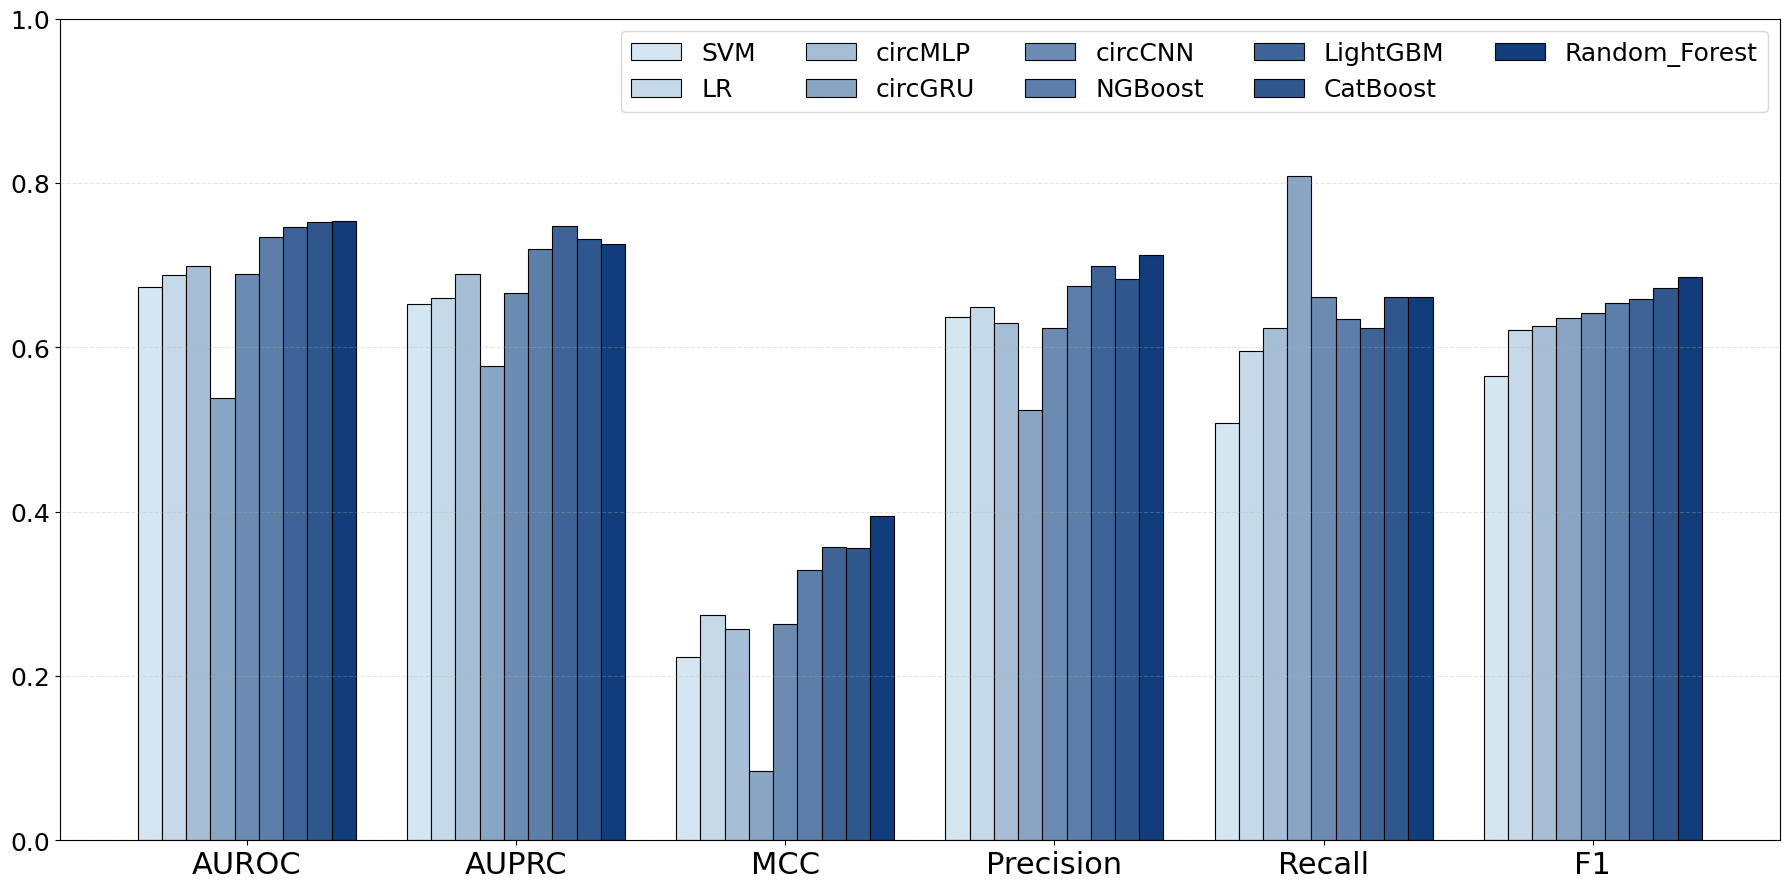

模型按F1从低到高排序:
1. SVM: F1 = 0.5653
2. LR: F1 = 0.6211
3. circMLP: F1 = 0.6264
4. circGRU: F1 = 0.6352
5. circCNN: F1 = 0.6419
6. NGBoost: F1 = 0.6535
7. LightGBM: F1 = 0.6590
8. CatBoost: F1 = 0.6722
9. Random_Forest: F1 = 0.6856


In [3]:
import matplotlib.pyplot as plt
import numpy as np


original_models = ['LR', 'SVM', 'CatBoost', 'LightGBM', 'Random_Forest', 'NGBoost', 'circCNN', 'circMLP', 'circGRU']
metrics = ['AUROC', 'AUPRC', 'MCC', 'Precision', 'Recall', 'F1']

# 原始数据矩阵 (模型 x 指标)
original_data = np.array([
    [0.6880, 0.6594, 0.2741, 0.6488, 0.5956, 0.6211],  # LR
    [0.6731, 0.6528, 0.2232, 0.6370, 0.5082, 0.5653],  # SVM
    [0.7522, 0.7311, 0.3554, 0.6836, 0.6612, 0.6722],  # CatBoost
    [0.7458, 0.7478, 0.3573, 0.6994, 0.6230, 0.6590],  # LightGBM
    [0.7530, 0.7262, 0.3944, 0.7118, 0.6612, 0.6856],  # Random_Forest
    [0.7342, 0.7195, 0.3285, 0.6744, 0.6339, 0.6535],  # NGBoost
    [0.6895, 0.6658, 0.2628, 0.6237, 0.6612, 0.6419],  # circCNN
    [0.6990, 0.6896, 0.2568, 0.6298, 0.6230, 0.6264],  # circMLP
    [0.5378, 0.5766, 0.0848, 0.5230, 0.8087, 0.6352]   # circGRU
])

# 根据F1排序（从低到高，最左侧最低，最右侧最高）
f1_idx = 5
f1_values = original_data[:, f1_idx] 
sorted_indices = np.argsort(f1_values) # 去掉 [::-1] 实现升序排列

# 重新排列模型和数据
models = [original_models[i] for i in sorted_indices]
data = original_data[sorted_indices]

# 配色方案 - 颜色依次加深
cool_colors = [
    '#D4E6F1', '#C5D9E8', '#B6CCDF', '#A7BFD6', '#98B2CD',
    '#89A5C4', '#7A98BB', '#6B8BB2', '#5C7EA9', '#4D71A0',
    '#3E6497', '#2F578E', '#204A85', '#113D7C'
]

# 为9个模型分配颜色，从浅到深均匀分布 (排在前面的F1低用浅色，排在后面的F1高用深色)
color_indices = [0, 1, 3, 5, 7, 8, 10, 11, 13]
model_colors = [cool_colors[i] for i in color_indices]

# 设置图形参数
fig, ax = plt.subplots(figsize=(18, 9)) # 适当加宽画布
n_metrics = len(metrics)
n_models = len(models)
bar_width = 0.09 # 调窄柱子宽度以容纳9个模型
x = np.arange(n_metrics)

# 绘制分组柱状图
for i, model in enumerate(models):
    offset = (i - n_models/2 + 0.5) * bar_width
    bars = ax.bar(x + offset, data[i], bar_width, 
                  label=model, color=model_colors[i], 
                  edgecolor='black', linewidth=0.8)

# 设置图形属性
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=22)
ax.tick_params(axis='y', labelsize=18)
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.legend(fontsize=18, loc='upper right', ncol=5) # 图例分卷两行排版

# 调整布局
plt.tight_layout()
plt.show()

# 打印排序后的模型顺序和对应的F1值
print("模型按F1从低到高排序:")
for i, model in enumerate(models):
    print(f"{i+1}. {model}: F1 = {data[i][f1_idx]:.4f}")